# Notebook 04 — ECM Deposit Repricing with Regime-Switching

We fit the hierarchical ECM model with Markov regime-switching betas to the
simulated ECM deposit rates (driven by real ECB factors from notebooks 02–03).

**Model:**
$$
\Delta r_{s,t} = \gamma_s \cdot \underbrace{(r_{s,t-1} - \alpha_s - \beta^L_{s,z_t} L_{t-1}
                - \beta^S_{s,z_t} S_{t-1} - \beta^C_s C_{t-1})}_{\text{ECT}^{(z_t)}_{s,t-1}}
                + \varepsilon_{s,t}
$$

The hidden Markov regime $z_t \in \{0, 1\}$ is marginalised via the **Hamilton filter**,
giving a differentiable likelihood for NUTS.

**Identification:** $\mu_{\beta L}^{(0)} < \mu_{\beta L}^{(1)}$ (low-rate vs hiking).

**Inputs:** `../data/ecb_data.pkl`, `../data/dl_results.pkl`

**Output:** `../data/ecm_results.pkl`

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pymc as pm
import arviz as az

from simulate import (
    SEGMENTS,
    TRUE_ALPHA, TRUE_GAMMA,
    TRUE_BETA_L_R0, TRUE_BETA_L_R1,
)
from ecm_repricing import (
    build_ecm_model,
    extract_regime_probs_numpy,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

## 1. Load Data

In [2]:
with open("../data/ecb_data.pkl", "rb") as f:
    ecb_data = pickle.load(f)

with open("../data/dl_results.pkl", "rb") as f:
    dl_results = pickle.load(f)

deposits         = ecb_data["deposits"]           # (T, S) simulated ECM deposit rates
regime_seq_true  = ecb_data["regime_seq"]         # (T,) true regimes
factors_filtered = dl_results["factors_filtered"] # (T, 3) DL-filtered factors
dates            = deposits.index

factors_arr  = factors_filtered.values.astype(np.float64)   # (T, 3)
deposits_arr = deposits.values.astype(np.float64)            # (T, S)

print(f"Factors shape:  {factors_arr.shape}")
print(f"Deposits shape: {deposits_arr.shape}")
print(f"Segments: {SEGMENTS}")
print(f"True regime distribution:")
print(regime_seq_true.value_counts().sort_index())

Factors shape:  (132, 3)
Deposits shape: (132, 4)
Segments: ['Retail Current', 'Retail Savings', 'SME Operational', 'Corporate']
True regime distribution:
regime
0    96
1    36
Name: count, dtype: int64


## 2. Prior Predictive Check

We check whether the prior on deposit rate changes $\Delta r$ covers the observed range.
The prior should be broad enough not to rule out the hiking-cycle dynamics,
where monthly changes were as large as +30bp.

C:\Users\thoma\AppData\Local\Temp\ipykernel_55796\3802270126.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior_idata = pm.sample_prior_predictive(samples=300, random_seed=0)


Sampling: [adj_z, alpha_z, beta_C_z, beta_L_z, beta_S_z, delta_beta_L, delta_beta_S, mu_alpha, mu_beta_C, mu_beta_L_0, mu_beta_S_0, mu_log_adj, p00, p11, sigma_alpha, sigma_beta_C, sigma_beta_L, sigma_beta_S, sigma_dep, sigma_log_adj]


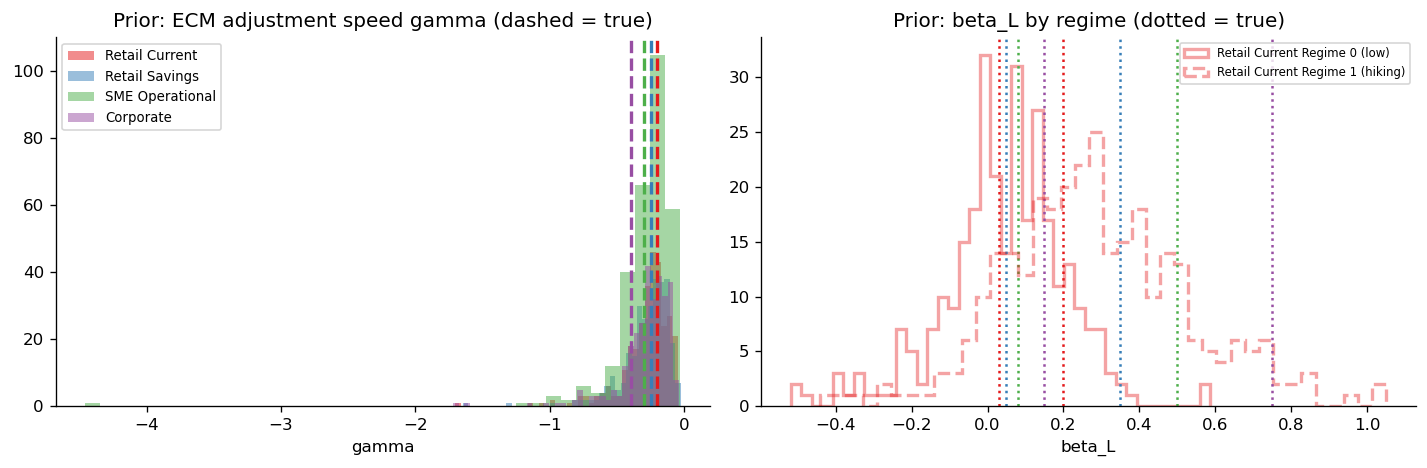

In [3]:
model = build_ecm_model(factors_arr, deposits_arr)

# Sample prior beta_L, gamma for predictive sense-check
with model:
    prior_idata = pm.sample_prior_predictive(samples=300, random_seed=0)

# Extract prior gamma and beta_L
gamma_prior  = prior_idata.prior["gamma"].values.reshape(-1, len(SEGMENTS))
beta_L_prior = prior_idata.prior["beta_L"].values.reshape(-1, 2, len(SEGMENTS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for s, (seg, c) in enumerate(zip(SEGMENTS, SEG_COLORS)):
    ax.hist(gamma_prior[:, s], bins=40, alpha=0.5, color=c, label=seg)
    ax.axvline(TRUE_GAMMA[s], color=c, lw=2, ls="--")
ax.set_title("Prior: ECM adjustment speed gamma (dashed = true)")
ax.set_xlabel("gamma")
ax.legend(fontsize=8)

ax = axes[1]
for k, (label, ls) in enumerate(zip(["Regime 0 (low)", "Regime 1 (hiking)"], ["-", "--"])):
    true_vals = [TRUE_BETA_L_R0, TRUE_BETA_L_R1][k]
    for s, (seg, c) in enumerate(zip(SEGMENTS, SEG_COLORS)):
        vals = beta_L_prior[:, k, s]
        if s == 0:
            ax.hist(vals, bins=40, alpha=0.4, color=c, histtype="step", lw=2, ls=ls,
                    label=f"{seg} {label}")
        ax.axvline(true_vals[s], color=c, lw=1.5, ls=":")
ax.set_title("Prior: beta_L by regime (dotted = true)")
ax.set_xlabel("beta_L")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

## 3. NUTS Sampling

The Hamilton filter likelihood is differentiable (computed via `pytensor.scan`),
so NUTS can sample the full joint posterior over regime probabilities and
model parameters simultaneously.

In [4]:
with model:
    idata_ecm = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )

print(az.summary(
    idata_ecm,
    var_names=[
        "p00", "p11",
        "mu_alpha", "mu_beta_L_0", "delta_beta_L", "mu_beta_L_1",
        "mu_log_adj",
    ],
))

C:\Users\thoma\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p00           0.943  0.059   0.823    0.998      0.005    0.004     158.0   
p11           0.949  0.036   0.884    0.998      0.001    0.001     925.0   
mu_alpha      0.983  0.223   0.549    1.390      0.007    0.006    1128.0   
mu_beta_L_0   0.100  0.078  -0.050    0.241      0.002    0.001    1306.0   
delta_beta_L  0.259  0.118   0.003    0.447      0.005    0.002     519.0   
mu_beta_L_1   0.359  0.100   0.170    0.544      0.003    0.002     891.0   
mu_log_adj   -1.307  0.251  -1.818   -0.870      0.007    0.004    1331.0   

              ess_tail  r_hat  
p00              729.0   1.02  
p11             1492.0   1.01  
mu_alpha        1615.0   1.00  
mu_beta_L_0     2326.0   1.00  
delta_beta_L     598.0   1.01  
mu_beta_L_1     2443.0   1.01  
mu_log_adj      2115.0   1.00  


## 4. Convergence Diagnostics

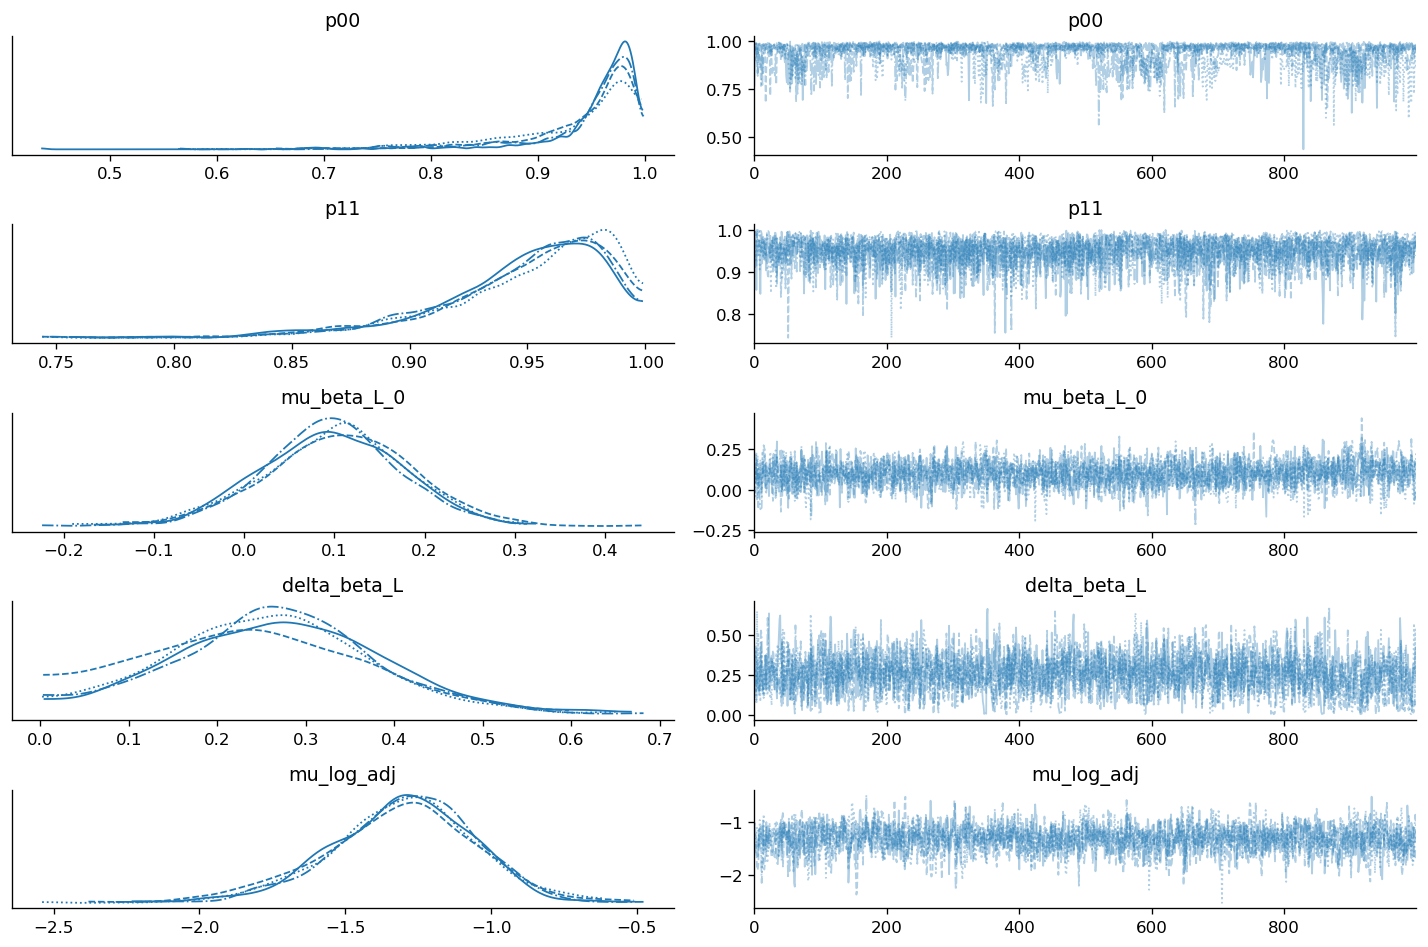

In [5]:
az.plot_trace(
    idata_ecm,
    var_names=["p00", "p11", "mu_beta_L_0", "delta_beta_L", "mu_log_adj"],
    figsize=(12, 8),
    compact=True,
)
plt.tight_layout()
plt.show()

## 5. Parameter Recovery: Adjustment Speeds (gamma)

The adjustment speed $\gamma_s$ is the core ECM parameter. It determines how quickly
deposit rates close the gap to the long-run equilibrium each month.

**Half-life:** $\tau_{1/2} = -\log(2)/\log(1+\gamma_s)$ months.

C:\Users\thoma\AppData\Local\Temp\ipykernel_55796\2803886120.py:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  gamma_hdi     = az.hdi(gamma_samples, hdi_prob=0.94)


ECM Adjustment Speeds (gamma)
Segment                   True    Mean   HDI 3%  HDI 97%   Half-life (mean)
---------------------------------------------------------------------------
Retail Current          -0.200  -0.203   -0.321   -0.073                3.0 months
Retail Savings          -0.250  -0.204   -0.312   -0.085                3.0 months
SME Operational         -0.300  -0.310   -0.436   -0.171                1.9 months
Corporate               -0.400  -0.525   -0.741   -0.278                0.9 months


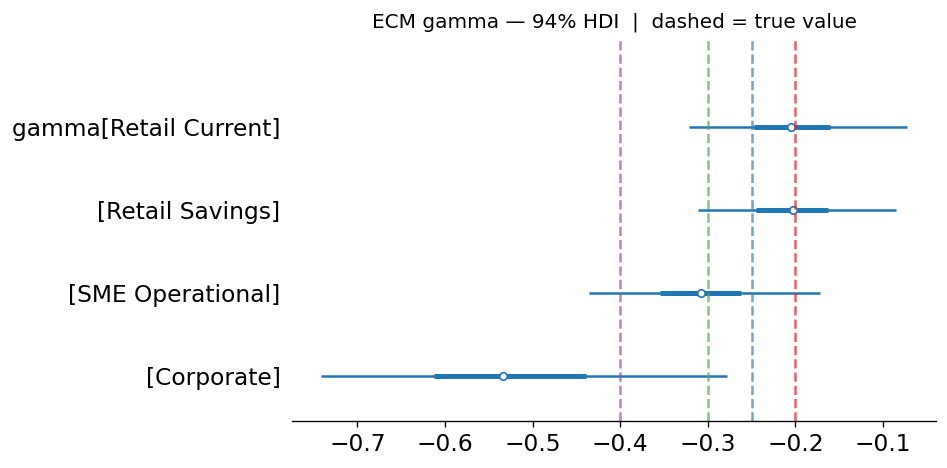

In [6]:
post = idata_ecm.posterior

gamma_samples = post["gamma"].values.reshape(-1, len(SEGMENTS))  # (N, S)
gamma_mean    = gamma_samples.mean(axis=0)
gamma_hdi     = az.hdi(gamma_samples, hdi_prob=0.94)

print("ECM Adjustment Speeds (gamma)")
print(f"{'Segment':<22} {'True':>7} {'Mean':>7} {'HDI 3%':>8} {'HDI 97%':>8} {'Half-life (mean)':>18}")
print("-" * 75)
for s, seg in enumerate(SEGMENTS):
    hdi_s = az.hdi(gamma_samples[:, s], hdi_prob=0.94)
    hl    = -np.log(2) / np.log(1 + gamma_mean[s])
    print(f"{seg:<22} {TRUE_GAMMA[s]:>7.3f} {gamma_mean[s]:>7.3f} "
          f"{hdi_s[0]:>8.3f} {hdi_s[1]:>8.3f} {hl:>18.1f} months")

# Forest plot
az.plot_forest(
    idata_ecm,
    var_names=["gamma"],
    combined=True,
    hdi_prob=0.94,
    figsize=(8, 4),
)
ax = plt.gca()
for s, (true_val, c) in enumerate(zip(TRUE_GAMMA[::-1], SEG_COLORS[::-1])):
    ax.axvline(true_val, color=c, lw=1.5, ls="--", alpha=0.7)
ax.set_title("ECM gamma — 94% HDI  |  dashed = true value")
plt.tight_layout()
plt.show()

## 6. Parameter Recovery: Regime-Specific Level Pass-Through (beta_L)

Level Pass-Through by Regime

Regime 0 (low rate):
  Segment                   True    Mean   HDI 3%  HDI 97%
  -------------------------------------------------------
  Retail Current           0.030   0.076   -0.136    0.322
  Retail Savings           0.050   0.083   -0.158    0.332
  SME Operational          0.080   0.148   -0.098    0.435
  Corporate                0.150   0.191   -0.165    0.451

Regime 1 (hiking):
  Segment                   True    Mean   HDI 3%  HDI 97%
  -------------------------------------------------------
  Retail Current           0.200   0.132    0.010    0.260
  Retail Savings           0.350   0.288    0.156    0.426
  SME Operational          0.500   0.428    0.312    0.569
  Corporate                0.750   0.656    0.504    0.828


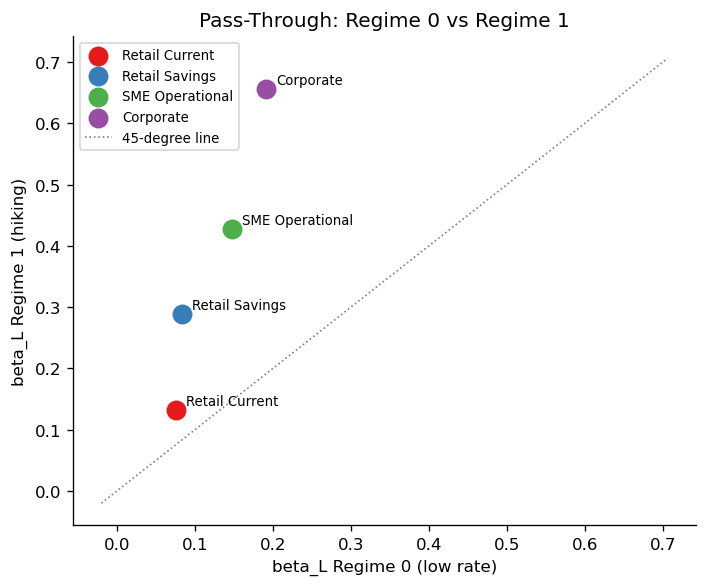

In [7]:
beta_L_samples = post["beta_L"].values.reshape(-1, 2, len(SEGMENTS))  # (N, 2, S)

print("Level Pass-Through by Regime")
for k, (regime_name, true_vals) in enumerate(
    zip(["Regime 0 (low rate)", "Regime 1 (hiking)"],
        [TRUE_BETA_L_R0, TRUE_BETA_L_R1])
):
    print(f"\n{regime_name}:")
    print(f"  {'Segment':<22} {'True':>7} {'Mean':>7} {'HDI 3%':>8} {'HDI 97%':>8}")
    print("  " + "-" * 55)
    for s, seg in enumerate(SEGMENTS):
        samples_ks = beta_L_samples[:, k, s]
        hdi_ks = az.hdi(samples_ks, hdi_prob=0.94)
        print(f"  {seg:<22} {true_vals[s]:>7.3f} {samples_ks.mean():>7.3f} "
              f"{hdi_ks[0]:>8.3f} {hdi_ks[1]:>8.3f}")

# Scatter: regime 0 vs regime 1 pass-through
beta_L_mean = beta_L_samples.mean(axis=0)  # (2, S)
fig, ax = plt.subplots(figsize=(6, 5))
for s, (seg, c) in enumerate(zip(SEGMENTS, SEG_COLORS)):
    ax.scatter(beta_L_mean[0, s], beta_L_mean[1, s], color=c, s=120, zorder=5, label=seg)
    ax.annotate(seg, (beta_L_mean[0, s], beta_L_mean[1, s]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)
lims = [min(beta_L_mean.min(), 0) - 0.02, beta_L_mean.max() + 0.05]
ax.plot(lims, lims, color="gray", lw=1, ls=":", label="45-degree line")
ax.set_xlabel("beta_L Regime 0 (low rate)")
ax.set_ylabel("beta_L Regime 1 (hiking)")
ax.set_title("Pass-Through: Regime 0 vs Regime 1")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Regime Transition Probabilities

The Markov transition matrix $P$ governs how long the system stays in each regime.

- **p00** = P(stay in regime 0 | regime 0): expected duration = $1/(1-p_{00})$ months
- **p11** = P(stay in regime 1 | regime 1): expected duration = $1/(1-p_{11})$ months

p00 (stay in regime 0): 0.943  -- expected duration: 17.4 months
p11 (stay in regime 1): 0.949  -- expected duration: 19.6 months


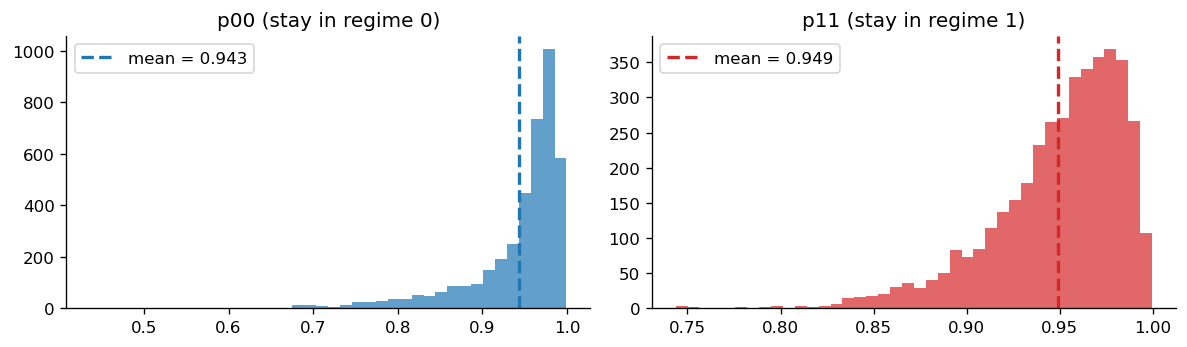

In [8]:
p00_samples = post["p00"].values.flatten()
p11_samples = post["p11"].values.flatten()

p00_mean = float(p00_samples.mean())
p11_mean = float(p11_samples.mean())

print(f"p00 (stay in regime 0): {p00_mean:.3f}  -- expected duration: {1/(1-p00_mean):.1f} months")
print(f"p11 (stay in regime 1): {p11_mean:.3f}  -- expected duration: {1/(1-p11_mean):.1f} months")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, samples, name, color in zip(
    axes,
    [p00_samples, p11_samples],
    ["p00 (stay in regime 0)", "p11 (stay in regime 1)"],
    ["#1f77b4", "#d62728"],
):
    ax.hist(samples, bins=40, color=color, alpha=0.7)
    ax.axvline(samples.mean(), color=color, lw=2, ls="--", label=f"mean = {samples.mean():.3f}")
    ax.set_title(name)
    ax.legend()
fig.tight_layout()
plt.show()

## 8. Filtered Regime Probabilities: P(z_t = 1 | y_{1:t})

We run the Hamilton filter in numpy with posterior mean parameters.
The filtered probability P(z_t = 1 | y_{1:t}) should rise sharply in 2022,
capturing the structural break in pass-through behaviour.

This is the analogue of the Kalman smoother for discrete hidden states.

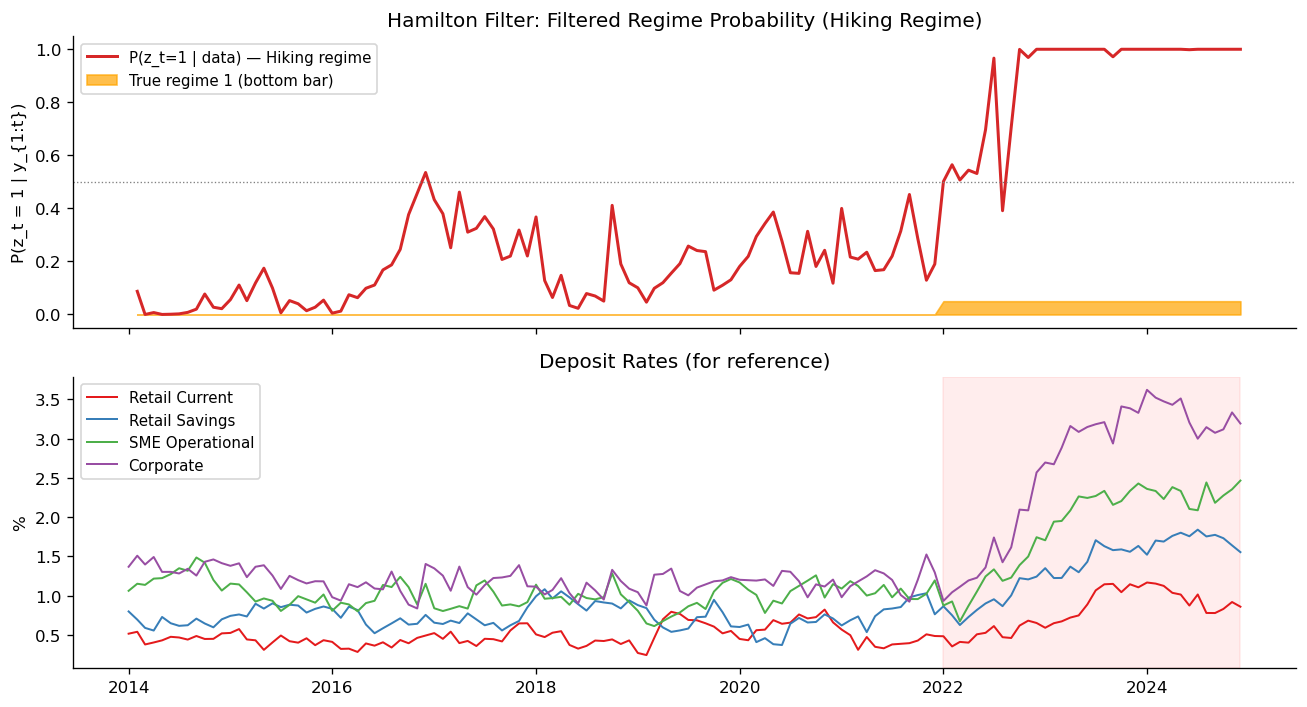

Regime classification accuracy (threshold 0.5): 98.5%


In [9]:
xi_filtered = extract_regime_probs_numpy(idata_ecm, factors_arr, deposits_arr)  # (T-1, 2)

# Dates for filtered probs (aligned to t=1,...,T-1)
dates_filt = dates[1:]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax = axes[0]
ax.plot(dates_filt, xi_filtered[:, 1], color="#d62728", lw=1.8,
        label="P(z_t=1 | data) — Hiking regime")
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
# Shade true regime-1 periods
true_r1 = regime_seq_true.values[1:] == 1
ax.fill_between(dates_filt, 0, true_r1.astype(float) * 0.05,
                color="orange", alpha=0.7, label="True regime 1 (bottom bar)")
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("P(z_t = 1 | y_{1:t})")
ax.set_title("Hamilton Filter: Filtered Regime Probability (Hiking Regime)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
for seg, c in zip(SEGMENTS, SEG_COLORS):
    ax.plot(dates, deposits_arr[:, SEGMENTS.index(seg)], color=c, lw=1.2, label=seg)
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.07, color="red")
ax.set_ylabel("%")
ax.set_title("Deposit Rates (for reference)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

# How well does the filter classify regimes?
predicted_regime = (xi_filtered[:, 1] > 0.5).astype(int)
true_regime_filt = regime_seq_true.values[1:]
accuracy = (predicted_regime == true_regime_filt).mean()
print(f"Regime classification accuracy (threshold 0.5): {accuracy:.1%}")

## 9. Posterior Predictive Check on Delta r

We check that the posterior predictive distribution of deposit rate changes covers
the observed $\Delta r$ distribution — particularly the larger moves in 2022.

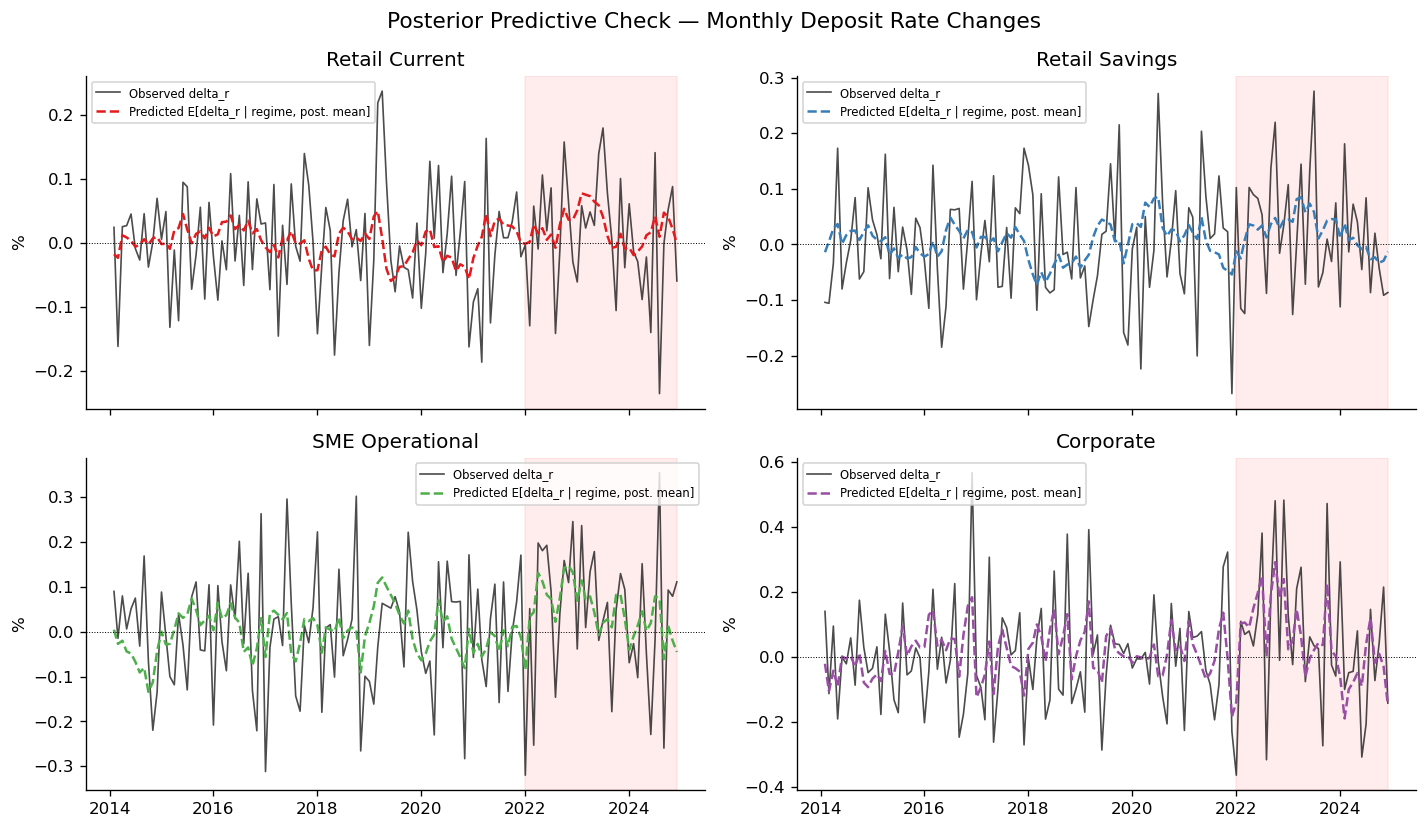

In [10]:
# Compute observed delta_r
delta_r_obs = deposits_arr[1:] - deposits_arr[:-1]  # (T-1, S)

# Simulate posterior predictive delta_r using posterior mean parameters
post_mean_gamma  = post["gamma"].mean(("chain", "draw")).values         # (S,)
post_mean_alpha  = post["alpha"].mean(("chain", "draw")).values         # (S,)
post_mean_beta_L = post["beta_L"].mean(("chain", "draw")).values        # (2, S)
post_mean_beta_S = post["beta_S"].mean(("chain", "draw")).values        # (2, S)
post_mean_beta_C = post["beta_C"].mean(("chain", "draw")).values        # (S,)
post_mean_sigma  = post["sigma_dep"].mean(("chain", "draw")).values     # (S,)
post_mean_p00    = float(post["p00"].mean(("chain", "draw")).values)
post_mean_p11    = float(post["p11"].mean(("chain", "draw")).values)

# Compute conditional mean delta_r using true regime (for PPC)
T_obs = len(dates_filt)
delta_r_pred_mean = np.zeros((T_obs, len(SEGMENTS)))
for t in range(T_obs):
    k      = regime_seq_true.values[t + 1]  # regime at t+1 (aligned to delta_r)
    L_t    = factors_arr[t, 0]
    S_t    = factors_arr[t, 1]
    C_t    = factors_arr[t, 2]
    r_eq   = (post_mean_alpha
              + post_mean_beta_L[k] * L_t
              + post_mean_beta_S[k] * S_t
              + post_mean_beta_C * C_t)
    ect    = deposits_arr[t] - r_eq
    delta_r_pred_mean[t] = post_mean_gamma * ect

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    ax.plot(dates_filt, delta_r_obs[:, s], color="black", lw=1.0, alpha=0.7, label="Observed delta_r")
    ax.plot(dates_filt, delta_r_pred_mean[:, s], color=c, lw=1.5, ls="--",
            label="Predicted E[delta_r | regime, post. mean]")
    ax.axhline(0, color="black", lw=0.6, ls=":")
    ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.07, color="red")
    ax.set_title(seg)
    ax.set_ylabel("%")
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Posterior Predictive Check — Monthly Deposit Rate Changes", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Save Results

In [11]:
results_ecm = {
    "idata":        idata_ecm,
    "xi_filtered":  pd.DataFrame(xi_filtered, index=dates_filt,
                                 columns=["P_regime_0", "P_regime_1"]),
}
with open("../data/ecm_results.pkl", "wb") as f:
    pickle.dump(results_ecm, f)
print("Saved to ../data/ecm_results.pkl")
print(f"Keys: {list(results_ecm.keys())}")

Saved to ../data/ecm_results.pkl
Keys: ['idata', 'xi_filtered']
